In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/NeoDaniyal/face-mask-detection.git

fatal: destination path 'face-mask-detection' already exists and is not an empty directory.


In [ ]:
%cd /content/face-mask-detection

/content/face-mask-detection


In [ ]:
!ls

config.py  __pycache__	README.md  requirement.txt  src


In [ ]:
!pip install -r requirement.txt

In [ ]:
import os
import torch

print("Current Directory:", os.getcwd())
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

Current Directory: /content/face-mask-detection
PyTorch Version: 2.11.0+cu128
CUDA Available: True


In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 963 bytes | 963.00 KiB/s, done.
From https://github.com/NeoDaniyal/face-mask-detection
   bd4d331..1b8c80a  main       -> origin/main
Updating bd4d331..1b8c80a
Fast-forward
 src/webcam_demo.py | 107 ++++++++++++++++++++++++++---------------------------
 1 file changed, 52 insertions(+), 55 deletions(-)


In [ ]:

import shutil
from pathlib import Path

# Paths
drive_split_dir = Path(
    "/content/drive/MyDrive/face-mask-detection/data/processed/split"
)
local_split_dir = Path("/content/data/processed/split")

print("Copying dataset from Google Drive to local Colab SSD...")
if local_split_dir.exists():
    shutil.rmtree(local_split_dir)

shutil.copytree(drive_split_dir, local_split_dir)
print("✅ Dataset copied successfully to local SSD!")

Copying dataset from Google Drive to local Colab SSD...
✅ Dataset copied successfully to local SSD!


In [ ]:
!pip uninstall -y opencv-python-headless opencv-python
!pip install opencv-python

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (73.8 MB)


In [ ]:
import cv2

print("OpenCV Version:", cv2.__version__)
cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
print("Cascade loaded successfully:", not cascade.empty())

OpenCV Version: 5.0.0


AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

In [ ]:
!PYTHONPATH=. python "src/webcam_demo.py" #Webcam script cannot run here becasue of Colab inverventions and multiple libraries error.

<IPython.core.display.Javascript object>
Traceback (most recent call last):
  File "/content/face-mask-detection/src/webcam_demo.py", line 101, in <module>
    run_colab_inference(threshold=0.19)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^
  File "/content/face-mask-detection/src/webcam_demo.py", line 69, in run_colab_inference
    img_data = eval_js("captureFrame()")
  File "/usr/local/lib/python3.13/dist-packages/google/colab/output/_js.py", line 36, in eval_js
    kernel = _ipython.get_kernel()
  File "/usr/local/lib/python3.13/dist-packages/google/colab/_ipython.py", line 24, in get_kernel
    return get_ipython().kernel
           ^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'kernel'


<IPython.core.display.Javascript object>

WEBCAM PREDICTION RESULT
Prediction : NO MASK
Confidence : 97.64%


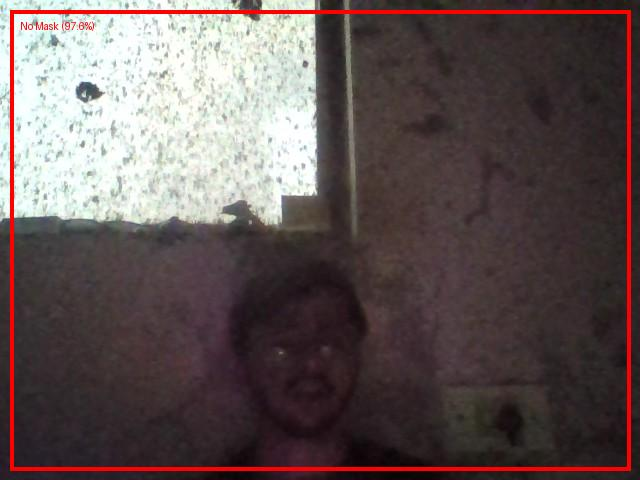

In [ ]:
import base64
import io
import sys
from pathlib import Path

# Set project paths
project_root = Path("/content/face-mask-detection")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
if str(project_root / "src") not in sys.path:
    sys.path.append(str(project_root / "src"))

from google.colab.output import eval_js
from IPython.display import Image as IPImage, Javascript, display
from PIL import Image, ImageDraw
import torch

from config import MODEL_DIR
from dataset import get_transforms
from model_transfer import MaskResNet18


def colab_capture_and_predict(threshold: float = 0.19) -> None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_path = MODEL_DIR / "resnet18_best.pth"

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Model checkpoint not found at {checkpoint_path}")

    # 1. Load Model
    model = MaskResNet18(dropout_rate=0.3).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    _, eval_transform = get_transforms()

    # 2. Browser JS Capture Trigger
    js = Javascript(
        """
        async function takePhoto() {
          const div = document.createElement('div');
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => setTimeout(resolve, 800));

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();
          return canvas.toDataURL('image/jpeg', 0.9);
        }
    """
    )
    display(js)
    data = eval_js("takePhoto()")

    # 3. Process Captured Frame
    binary_data = base64.b64decode(data.split(",")[1])
    pil_img = Image.open(io.BytesIO(binary_data)).convert("RGB")

    tensor = eval_transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        prob_no_mask = torch.sigmoid(logits).squeeze().item()

    is_no_mask = prob_no_mask >= threshold
    label = "No Mask" if is_no_mask else "Mask"
    conf = prob_no_mask if is_no_mask else (1.0 - prob_no_mask)
    color = "red" if is_no_mask else "green"

    # 4. Draw Overlay
    draw = ImageDraw.Draw(pil_img)
    w, h = pil_img.size
    draw.rectangle([10, 10, w - 10, h - 10], outline=color, width=4)
    draw.text((20, 20), f"{label} ({conf * 100:.1f}%)", fill=color)

    # 5. Save and Display Result
    save_path = project_root / "outputs/plots/webcam_prediction.jpg"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    pil_img.save(save_path)

    print("=" * 50)
    print("WEBCAM PREDICTION RESULT")
    print("=" * 50)
    print(f"Prediction : {label.upper()}")
    print(f"Confidence : {conf * 100:.2f}%")
    print("=" * 50)

    display(IPImage(filename=str(save_path)))


# Execute directly in Colab cell
colab_capture_and_predict(threshold=0.19)